# **📌 INTRODUCTION**

The idea for Fraud Flagr came from my experience working as a BSA (Business Systems Analyst) in Fraud Strategy at TD Bank. In the fast-evolving landscape of financial fraud, I saw firsthand how fraudsters constantly adapt, while many detection systems still rely heavily on rigid, rule-based tools. These tools often require frequent manual updates and can either miss fraud or over-flag legitimate transactions.

With the growing accessibility of AI, I wanted to explore how machine learning could help detect fraud in a smarter, more adaptive way. That curiosity led me to build Fraud FlagR, an end-to-end ML fraud detection project.

To simulate real-world conditions, I used the [PaySim dataset](https://www.kaggle.com/datasets/ealaxi/paysim1), which is based on mobile money transactions. This dataset captures realistic transaction behavior (though simulated) and includes relevant pre-defined features like transaction type, amount, origin and destination balances, and fraud labels. It offered a strong foundation to experiment with fraud patterns and test different model approaches.

## **🎯 Goals**



*   Build machine learning models to detect fraudulent transactions with high accuracy
*   Minimize false positives to avoid flagging legitimate user activity
*   Evaluate model performance using both technical and business impact metrics
*   Explore model interpretability and scalability for practical deployment
*   Identify next steps for improvement

# **📥 DATA LOADING AND INSPECTION**

In [ ]:
import kagglehub
import pandas as pd
import seaborn as sns
import os
import numpy as np

#download the dataset
path = kagglehub.dataset_download("ealaxi/paysim1")

#check what files were downloaded
print("Files in dataset folder:", os.listdir(path))

#load the csv (adjust filename based on output from step 2)
file_path = os.path.join(path, "PS_20174392719_1491204439457_log.csv")  # This is the known CSV name for PaySim

#read the csv using pandas
df = pd.read_csv(file_path)

#view top 10 rows
print(df.head(10))

Files in dataset folder: ['PS_20174392719_1491204439457_log.csv']
   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815      170136.00       160296.36   
1     1   PAYMENT   1864.28  C1666544295       21249.00        19384.72   
2     1  TRANSFER    181.00  C1305486145         181.00            0.00   
3     1  CASH_OUT    181.00   C840083671         181.00            0.00   
4     1   PAYMENT  11668.14  C2048537720       41554.00        29885.86   
5     1   PAYMENT   7817.71    C90045638       53860.00        46042.29   
6     1   PAYMENT   7107.77   C154988899      183195.00       176087.23   
7     1   PAYMENT   7861.64  C1912850431      176087.23       168225.59   
8     1   PAYMENT   4024.36  C1265012928        2671.00            0.00   
9     1     DEBIT   5337.77   C712410124       41720.00        36382.23   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0    

In [ ]:
#rename oldbalanceOrg to oldbalanceOrig
df = df.rename(columns={'oldbalanceOrg': 'oldbalanceOrig'})

#add new column (netOrig) newbalanceOrg - oldbalanceOrg
df['netOrig'] = df['newbalanceOrig'] - df['oldbalanceOrig']

#add column newDest = newbalanceDest - oldbalanceDest
df['netDest'] = df['newbalanceDest'] - df['oldbalanceDest']
print(df.head(10))

   step      type    amount     nameOrig  oldbalanceOrig  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.00       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.00        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.00            0.00   
3     1  CASH_OUT    181.00   C840083671          181.00            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.00        29885.86   
5     1   PAYMENT   7817.71    C90045638        53860.00        46042.29   
6     1   PAYMENT   7107.77   C154988899       183195.00       176087.23   
7     1   PAYMENT   7861.64  C1912850431       176087.23       168225.59   
8     1   PAYMENT   4024.36  C1265012928         2671.00            0.00   
9     1     DEBIT   5337.77   C712410124        41720.00        36382.23   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  \
0  M1979787155             0.0            0.00        0               0   
1  M204428222

# **🕵️‍♀️ EXPLORATORY DATA ANALYSIS**

Before modeling, I explored the dataset to understand class distribution, key fraud patterns, and potential risk indicators.

In [ ]:
#is the dataset imbalanced?
df["isFraud"].value_counts(normalize=True) #insight: imbalanced dataset

,proportion
isFraud,
0,0.998709
1,0.001291


***📉 Exhibit 1: Fraud Label Distribution***

This table shows the proportion of fraudulent vs. non-fraudulent transactions:

**🔍 Insight:**

The dataset is heavily imbalanced, with fraud making up a very small portion of transactions.

**📌 Implications:**

Standard classifiers may perform poorly due to bias toward the majority class. Will need to handle class imbalance via techniques like resampling, weighting, or specialized algorithms.

Reflects the real-world challenge where fraud is rare but high-risk, so high recall is crucial even at low base rates.

In [ ]:
#certain transaction types more likely to be fraud?
df.groupby(["type", "isFraud"]).size().unstack(fill_value=0)

isFraud,0,1
type,,
CASH_IN,1399284,0
CASH_OUT,2233384,4116
DEBIT,41432,0
PAYMENT,2151495,0
TRANSFER,528812,4097


***🧾 Exhibit 2: Transaction Type vs. Fraud***

This table breaks down fraud occurrence by transaction type:

**🔍 Insight:** Fraud is highly concentrated in specific transaction types, particularly TRANSFER and CASH_OUT.

**📌 Implications:** Transaction type will likely be a highly informative feature for modeling. Could also use one-hot encoding or flag-based feature engineering.

<Axes: xlabel='isFraud', ylabel='amount'>

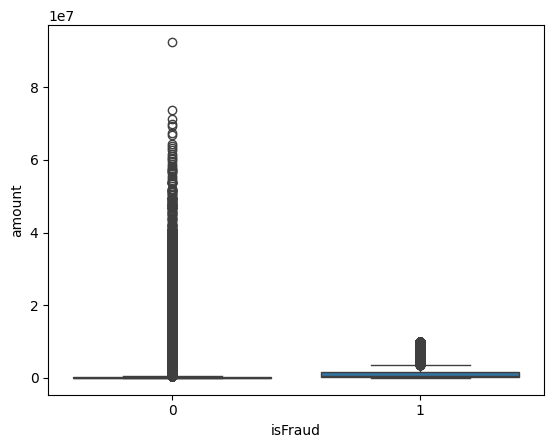

In [ ]:
#fraud amt distribution
sns.boxplot(x='isFraud', y='amount', data=df)

***💸 Exhibit 3: Fraud Amount Distribution***

This boxplot compares the transaction amount distributions for fraudulent and non-fraudulent transactions:

**🔍 Insight:** Fraudulent transactions tend to fall within a narrower and often moderate amount range, while non-fraudulent ones show a wider and more varied distribution.

**📌 Implications:** This doesn't fully align with real-world patterns, where fraud can occur across a broader spectrum, from small scams to high-value theft.

# **⚙️ FEATURE ENGINEERING**

In [ ]:
##one-hot encode the 'type' column
df = pd.get_dummies(df, columns=['type'], drop_first=False)

###HOUR OF DAY
# Extract hour of day from step
df['transactionHour'] = df['step'] % 24

###ACCOUNT AGE
# Find first time each sender was seen
first_seen = df.groupby('nameOrig')['step'].min().reset_index()
first_seen.columns = ['nameOrig', 'firstStep']

# Merge into df
df = df.merge(first_seen, on='nameOrig', how='left')

# Calculate account age
df['accountAge'] = df['step'] - df['firstStep']

###TRANSACTIONS TODAY
# Add day column
df['day'] = df['step'] // 24

# Count transactions per sender per day
daily_trans = df.groupby(['nameOrig', 'day']).size().reset_index(name='numTransToday')

# Merge into main df
df = df.merge(daily_trans, on=['nameOrig', 'day'], how='left')

###TO MERCHANT?
df['isToMerchant'] = df['nameDest'].str.startswith('M').astype(int)

###PAST FRAUD
# First, sort by step so earlier transactions come first
df = df.sort_values('step')

# Flag if nameOrig has sent fraud before
df['prevFraudSender'] = df.groupby('nameOrig')['isFraud'].cumsum().shift(1).fillna(0)
df['prevFraudSender'] = (df['prevFraudSender'] > 0).astype(int)

# Flag if nameDest has received fraud before
df['prevFraudReceiver'] = df.groupby('nameDest')['isFraud'].cumsum().shift(1).fillna(0)
df['prevFraudReceiver'] = (df['prevFraudReceiver'] > 0).astype(int)

# Combine
df['prevFraud'] = df[['prevFraudSender', 'prevFraudReceiver']].max(axis=1)

# Optional: drop helpers
df = df.drop(columns=['prevFraudSender', 'prevFraudReceiver'])


print(df.head(10))

      step     amount     nameOrig  oldbalanceOrig  newbalanceOrig  \
2129     1   42012.45  C1137667747       350501.24       350501.24   
2119     1    5831.05  C1723848804       333749.58       327918.53   
2120     1    9855.36   C570422884       327918.53       318063.17   
2121     1   10726.49   C509806761       318063.17       307336.68   
2122     1    1833.22  C1859928417        57589.00        55755.78   
2123     1   34115.82  C1378280450        32043.00            0.00   
2124     1    2210.66   C339788561        32902.00        30691.34   
2125     1   22190.99  C2017380745        52231.01        30040.03   
2126     1  168451.53   C501036152        30040.03       198491.56   
2127     1  123545.77   C261567641       198491.56       322037.33   

         nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  \
2129   C667346055       350501.24      9291619.62        0               0   
2119  M1252820474            0.00            0.00        0               

In this step, I moved beyond raw inputs and created features that reflect user behavior and transaction context, both of which are crucial for detecting fraud patterns that aren’t obvious from amounts alone.

**🔹 One-Hot Encoding Transaction Type**

To make the type column usable for machine learning, I converted it into multiple binary columns, one for each transaction type (e.g., TRANSFER, CASH_OUT). This allows the model to learn risk patterns specific to each type without assuming an ordinal relationship between categories.

**🔹 Hour of Transaction**

By extracting the transaction hour from the step column (which represents hours since simulation start), we capture time-of-day trends. Fraud may cluster during unusual hours (e.g., late night), which a model can learn from.

**🔹 Account Age (How long has this sender been active?)**

I calculated the number of hours since the account (nameOrig) was first seen. New accounts may be riskier, especially if they immediately initiate large or suspicious transactions, a common fraud identification tactic.

**🔹 Transaction Frequency (per day)**

I created a feature that counts how many times a sender transacts in a given day. Unusually high activity can be a red flag, especially if it's inconsistent with the account's historical behavior.

**🔹 Is the Receiver a Merchant?**

In this dataset, receivers starting with "M" are merchants. This flag helps the model understand whether money is being sent to a business or an individual.

**🔹 History of Fraud**

I added flags indicating whether the sender or receiver has previously been involved in a fraudulent transaction. Accounts with past fraud activity, even indirectly, can signal risky behavior or suspicious networks.

In [ ]:
# Calculate absolute transaction ratio (no negative values)
df['ratioOrig'] = abs(df['netOrig']) / df['oldbalanceOrig']

# Replace NaN (from division by zero) with -1
df['ratioOrig'] = df['ratioOrig'].fillna(-1)

# Replace infinity with -2
df['ratioOrig'] = df['ratioOrig'].replace([np.inf, -np.inf], -2)

count_minus_1 = (df['ratioOrig'] == -1).sum()
count_minus_2 = (df['ratioOrig'] == -2).sum()
print(f"Number of -1 values in ratioOrig (from division by 0): {count_minus_1}")
print(f"Number of -2 values in ratioOrig (from infinity replacement): {count_minus_2}")

Number of -1 values in ratioOrig (from division by 0): 2088985
Number of -2 values in ratioOrig (from infinity replacement): 13464


In [ ]:
#signal fake accounts
# will =1 if old and new balance of destination are both 0
df['zeroBalanceFlag'] = ((df['oldbalanceDest'] == 0) & (df['newbalanceDest'] == 0)).astype(int)

#isHighValue = 1 if transaction amt in top 10% of all amounts
#calculate 90th percentile
threshold_df = df['amount'].quantile(0.90)

#create the flag
df['isHighValue'] = (df['amount'] > threshold_df).astype(int)

#check how many got flagged
print("Total Transactions (all transactions): ", len(df))
print("Zero balance destination count (all transactions):", df['zeroBalanceFlag'].sum())
print("High value transactions count (all transactions):", df['isHighValue'].sum())

Total Transactions (all transactions):  6362620
Zero balance destination count (all transactions): 2317282
High value transactions count (all transactions): 636262


**🔹 Transaction Amount Ratio**

I calculated the absolute ratio of the amount being transferred relative to the sender’s original balance. This helps identify cases where users are draining their entire balance (a common fraud signal). To handle division by zero or infinity, I filled resulting NaN values with -1 and inf values with -2 to preserve those edge cases in a model-friendly way instead of dropping them.

**🔹 Fake or Inactive Destination Accounts**

Fraudsters often move money to newly created or fake accounts with no transaction history. I flagged transactions where both the old and new destination balances were 0, which can indicate such dummy accounts.

**🔹 High-Value Transaction Flag**

Fraud losses are especially dangerous when large amounts are involved. I flagged transactions that fall in the top 10% of all transaction amounts. This allows the model to give special attention to high-risk, high-stakes scenarios.

### **💡 Why This Matters**

Raw transaction data alone often lacks the context needed to accurately detect fraud, especially when fraudulent behavior mimics legitimate activity. Feature engineering bridges that gap by creating behavioral signals, historical context, and risk flags that help the model see beyond surface-level patterns.

In this case, features like account age, transaction frequency, and time of day give the model a sense of user behavior over time, while others like past fraud history, high-value transaction flags, and suspicious balance activity help highlight riskier transactions that warrant closer attention.

By also handling edge cases, like divisions by zero or infinite ratios, we preserve potentially meaningful anomalies without introducing noise or errors. Altogether, these engineered features make the model more robust, more explainable, and more capable of catching fraud that would otherwise slip through the cracks.

# **📈 LOGISTIC REGRESSION**

## **🧩 Model Setup and Training**

In [ ]:
#drop text columns before training
#df = df.drop(['nameOrig', 'nameDest', 'day', 'firstStep'], axis=1)

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

#clone the original dataframe so we don’t mess with it
df_logistic = df.copy()
df_logistic = df_logistic.drop(['nameOrig', 'nameDest', 'day', 'firstStep'], axis=1)

#load data
X = df_logistic.drop("isFraud", axis=1)  # all columns except the label
y = df_logistic["isFraud"]               # the label column

#split into training and testing sets, 20% for testing, consistent shuffle
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#standardize all features to same scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#create and train the logistic regression model
model_logistic = LogisticRegression(class_weight='balanced', max_iter=100)  #balance dataset, default tolerance 1e-4 or 1000 max iterations
model_logistic.fit(X_train_scaled, y_train)   #finds best weights for each feature using Gradient Descent
#code below takig too long so havent tested yet lol
#model_logistic = LogisticRegression(penalty='l1', solver='saga', class_weight='balanced', max_iter=1000) #<-- l1 automatically drops unipmortant features and changed solver to saga since it better with imbalanced datasets or so ive heard
#model_logistic.fit(X_train_scaled, y_train)

#predict fraud on the test set
#y_pred = model_logistic.predict(X_test_scaled) <-- this classified as fraud is probability was >0.5 but since dataset is imbalanced we might have to up it
y_probs = model_logistic.predict_proba(X_test_scaled)[:, 1]  # get fraud probabilities
y_pred = (y_probs > 0.6).astype(int)  # label as fraud only if prob > 0.6

#evaluate how the model did
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Confusion Matrix:
[[1259495   11402]
 [     56    1571]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00   1270897
           1       0.12      0.97      0.22      1627

    accuracy                           0.99   1272524
   macro avg       0.56      0.98      0.61   1272524
weighted avg       1.00      0.99      0.99   1272524



***📄 Exhibit 4: Initial Logistic Regression Classification Report and Confusion Matrix***

**🛠️ Approach and Reasoning:**
* Removed identifying text columns (nameOrig, nameDest, day, firstStep) from the dataset
* Split data into 80% training and 20% testing sets for robust evaluation
* Applied feature scaling with StandardScaler to normalize feature ranges and improve model convergence
* Used class_weight='balanced' in Logistic Regression to address class imbalance by emphasizing minority fraud class
* Limited maximum iterations to 100 to reflect an initial baseline model
* Set classification threshold to 0.6 (instead of default 0.5) to increase recall of fraud cases while controlling false positives

**📝 Performance Overview**

This setup yields high recall (approx 97%), successfully catching most fraud, but relatively low precision (approx 12%), indicating many false positives. The balance weighting and scaling help model performance, but further tuning and threshold adjustments are needed to better balance precision and recall.

## **🔄 Hyperparameter Tuning & Model Optimization**

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer, average_precision_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from scipy.stats import loguniform
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

#define features and label
X = df_logistic.drop("isFraud", axis=1)
y = df_logistic['isFraud']

#split training and testing dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#build pipeline: scale + logistic regression
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(class_weight='balanced', max_iter=1000))
])

#search space
param_dist = {
    'logreg__C': loguniform(1e-4, 1e2),           # Inverse of regularization strength
    'logreg__penalty': ['l2'],
}

#define custom scorer with threshold (from prev trial and error)
def f1_with_threshold(threshold=0.95):
    def scorer(estimator, X, y):
        probs = estimator.predict_proba(X)[:, 1]
        preds = (probs > threshold).astype(int)
        return f1_score(y, preds)
    return make_scorer(scorer, greater_is_better=True)

scorer = f1_with_threshold(0.95)

#randomized Search
search = RandomizedSearchCV(pipeline, param_distributions=param_dist,
                            n_iter=20, #20 diff combos
                            scoring=scorer, #uses f1 for scoring
                            cv=3, #splits training dataset into 3 parts for cross validation
                            verbose=2, n_jobs=-1, random_state=42)

#fit
search.fit(X_train, y_train)

#best model details
print("Best Parameters:", search.best_params_)

#predict on test
y_probs = search.predict_proba(X_test)[:, 1]

from sklearn.metrics import precision_recall_curve, average_precision_score
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
ap = average_precision_score(y_test, y_probs)

print(f"Average Precision on Test Set: {ap:.4f}")


Fitting 3 folds for each of 20 candidates, totalling 60 fits


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan]
  warnings.warn(


Best Parameters: {'logreg__C': np.float64(0.017670169402947963), 'logreg__penalty': 'l2'}
Average Precision on Test Set: 0.8839


**🛠️ Approach and Reasoning:**

* Kept the same data preprocessing steps: dropped text identifiers and split data into 80% training and 20% testing
* Built a pipeline combining feature scaling (StandardScaler) and logistic regression with class_weight='balanced' to manage imbalance
* Increased max iterations to 1000 for better convergence
* Defined a hyperparameter search over a wide range of regularization strengths (C) using randomized search with cross-validation to efficiently find the best model
* Created a custom F1 scorer applying a high classification threshold (0.95) to reflect the importance of minimizing false positives while maintaining fraud recall
* Used 3-fold cross-validation during search to ensure model robustness and avoid overfitting

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

#predict 0 or 1 using threshold
y_pred = (y_probs >= 0.95).astype(int)

#print classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

#confusion Matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix:")
print(cm)


Classification Report:
              precision    recall  f1-score   support

           0     0.9999    0.9988    0.9994   1270897
           1     0.4992    0.9146    0.6458      1627

    accuracy                         0.9987   1272524
   macro avg     0.7495    0.9567    0.8226   1272524
weighted avg     0.9993    0.9987    0.9989   1272524


Confusion Matrix:
[[1269404    1493]
 [    139    1488]]


***📄 Exhibit 5: Tuned Logistic Regression Classification Report and Confusion Matrix***

**📝 Performance Overview**
* The tuned model achieves a higher average precision score (area under precision-recall curve), indicating better ranking of fraud probabilities
* At the strict threshold of 0.95, classification metrics show improved precision and balanced recall compared to baseline
* Confusion matrix reflects fewer false positives and more confident fraud detection, aligning better with business goals of minimizing customer friction and financial loss
* These improvements demonstrate the value of hyperparameter tuning and threshold adjustment on imbalanced fraud data

## **💰 Financial Impact Analysis**

In [ ]:
#add predictions back to test set for analysis
X_test_copy = X_test.copy()
X_test_copy['true_label'] = y_test.values #add true labels and predictions
X_test_copy['predicted'] = y_pred
X_test_copy['amount'] = X.loc[X_test_copy.index, 'amount']  #pull amount column from original

#fn
fn_log = X_test_copy[(X_test_copy['true_label'] == 1) & (X_test_copy['predicted'] == 0)]
total_FN_loss_log = fn_log['amount'].sum()

#fp
fp_log = X_test_copy[(X_test_copy['true_label'] == 0) & (X_test_copy['predicted'] == 1)]
total_FP_loss_log = fp_log['amount'].sum()

#tp
tp_log = X_test_copy[(X_test_copy['true_label'] == 1) & (X_test_copy['predicted'] == 1)]
total_TP_saved_log = tp_log['amount'].sum()

total_test_amount_log = X_test_copy['amount'].sum()


print(f"💸 Undetected Fraud (False Negatives): ${total_FN_loss_log:,.2f}")
print(f"💸 Legit Transactions Flagged (False Positives): ${total_FP_loss_log:,.2f}")
print(f"💰 Fraud Caught and Saved (True Positives): ${total_TP_saved_log:,.2f}")
print(f"📊 Total $ Value of All Test Transactions: ${total_test_amount_log:,.2f}")

💸 Undetected Fraud (False Negatives): $28,913,376.07
💸 Legit Transactions Flagged (False Positives): $438,450,823.23
💰 Fraud Caught and Saved (True Positives): $2,243,414,364.65
📊 Total $ Value of All Test Transactions: $228,513,915,447.56


**💲 Exhibit 6: Logistic Regression Financial Impact Summary**

## **💵 Performance Evaluation**
The model identified over \$2.24B in fraudulent transactions, showcasing its effectiveness in capturing high-risk cases. However, \$28.9M in fraud went undetected, and \$438.5M in legitimate transactions were wrongly flagged which is a significant volume of false positives that could disrupt customer experience and increase operational review costs.

Quantitatively, the cost of false positives far outweighs that of missed fraud, meaning the model is aggressive in catching fraud but possibly too conservative in labeling legitimate activity. Qualitatively, this could lead to poor user trust, increased volume of calls as call centers, and reputational harm, especially if legitimate users face friction accessing their funds.

**📊 FEATURE IMPORTANCE**

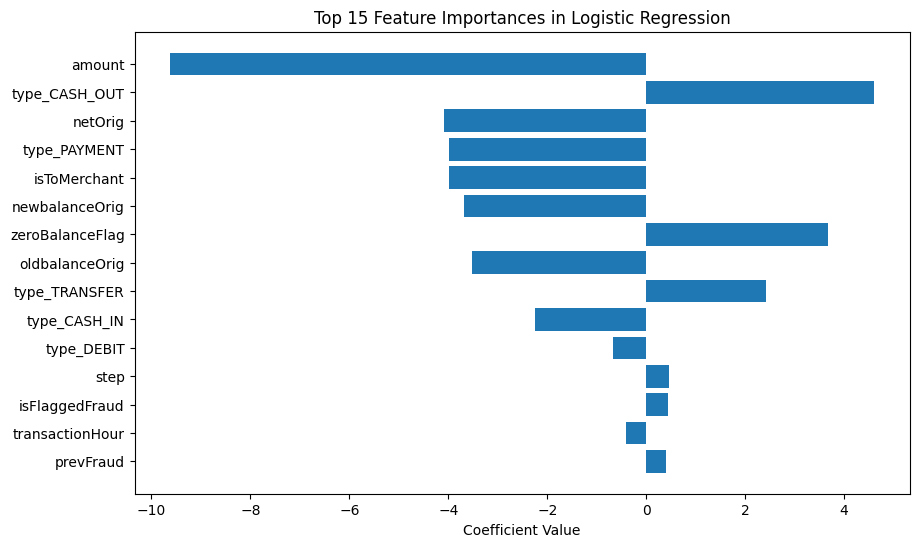

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

#feature importance
coef = model_logistic.coef_[0]
features = X.columns

#create DataFrame
feat_imp = pd.DataFrame({'feature': features, 'coefficient': coef})

#sort by absolute value of coefficient
feat_imp['abs_coef'] = feat_imp['coefficient'].abs()
feat_imp = feat_imp.sort_values(by='abs_coef', ascending=False).head(15)  # top 15 features

#plot
plt.figure(figsize=(10,6))
plt.barh(feat_imp['feature'], feat_imp['coefficient'])
plt.xlabel('Coefficient Value')
plt.title('Top 15 Feature Importances in Logistic Regression')
plt.gca().invert_yaxis()  # highest importance on top
plt.show()

***Exhibit 7: Top 15 Feature Importances***

Identified the top 15 features driving fraud predictions using logistic regression coefficients. This helps interpret model behavior and informs future feature selection or rule-based strategies.

# **🌳 RANDOM FOREST**

## **🧩 Model Setup and Training**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd

#create a copy of dataframe for Random Forest
df_rf = df.copy()
df_rf.drop(['nameOrig', 'nameDest'], axis=1, inplace=True)
#NOTE: Transactions which are detected as fraud are cancelled, so for fraud detection these columns (oldbalanceOrg, newbalanceOrig, oldbalanceDest, newbalanceDest ) must not be used.
df_rf.drop(['oldbalanceOrig', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest'], axis=1, inplace=True)

#prepare features and target with new variable names
X_rf = df_rf.drop('isFraud', axis=1)
y_rf = df_rf['isFraud']

#split data
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X_rf, y_rf, test_size=0.2, random_state=42)

#initialize Random Forest model
model_rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

#train model
model_rf.fit(X_train_rf, y_train_rf)

#predict on test set
y_pred_rf = model_rf.predict(X_test_rf)

#evaluate
print("Confusion Matrix:")
print(confusion_matrix(y_test_rf, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test_rf, y_pred_rf))


Confusion Matrix:
[[1270870      27]
 [    189    1438]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270897
           1       0.98      0.88      0.93      1627

    accuracy                           1.00   1272524
   macro avg       0.99      0.94      0.97   1272524
weighted avg       1.00      1.00      1.00   1272524



***📄 Exhibit 8: Initial Random Forest Classification Report and Confusion Matrix***

**🛠️ Approach and Reasoning**



**📝 Performance Overview**


## **🔄 Hyperparameter Tuning and Model Optimization**

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, f1_score

#reuse X_rf, y_rf from previous step
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X_rf, y_rf, test_size=0.2, random_state=42)

#define the random forest pipeline
rf_pipeline = Pipeline([
    ('rf', RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1))
])

#define the parameter search space
param_dist_rf = {
    'rf__n_estimators': randint(100, 150),
    'rf__max_depth': [None] + list(range(5, 20)),
    'rf__min_samples_split': randint(2, 10),
    'rf__min_samples_leaf': randint(1, 5),
    'rf__max_features': ['sqrt', 'log2', None]
}

#define custom scorer (using F1 to balance precision/recall)
def f1_threshold_scorer(threshold=0.5):
    def scorer(estimator, X, y):
        probs = estimator.predict_proba(X)[:, 1]
        preds = (probs > threshold).astype(int)
        return f1_score(y, preds)
    return make_scorer(scorer)

#run randomized search
search_rf = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_dist_rf,
    n_iter=10,
    scoring=f1_threshold_scorer(0.5),
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

#fit search
search_rf.fit(X_train_rf, y_train_rf)

#show best parameters
print("🔍 Best Hyperparameters:")
print(search_rf.best_params_)

#predict using best model
best_rf = search_rf.best_estimator_
y_probs_rf = best_rf.predict_proba(X_test_rf)[:, 1]
y_pred_rf = (y_probs_rf > 0.5).astype(int)  # or adjust threshold later if needed

#evaluate
from sklearn.metrics import classification_report, confusion_matrix
print("\nClassification Report:")
print(classification_report(y_test_rf, y_pred_rf, digits=4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_rf, y_pred_rf))

Fitting 3 folds for each of 10 candidates, totalling 30 fits


/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


***📄 Exhibit 9: Tuned Random Forest Classification Report and Confusion Matrix***

## **💰 Financial Impact Analysis**

In [ ]:
#add predictions back to test set for analysis
X_test_rf_copy = X_test_rf.copy()
X_test_rf_copy['true_label'] = y_test_rf
X_test_rf_copy['predicted'] = y_pred_rf
X_test_rf_copy['amount'] = X_rf.loc[X_test_rf_copy.index, 'amount']  # pull amount column from original

#fn
fn = X_test_rf_copy[(X_test_rf_copy['true_label'] == 1) & (X_test_rf_copy['predicted'] == 0)]
total_FN_loss = fn['amount'].sum()

#fp
fp = X_test_rf_copy[(X_test_rf_copy['true_label'] == 0) & (X_test_rf_copy['predicted'] == 1)]
total_FP_loss = fp['amount'].sum()

#tp
tp = X_test_rf_copy[(X_test_rf_copy['true_label'] == 1) & (X_test_rf_copy['predicted'] == 1)]
total_TP_saved = tp['amount'].sum()

total_test_amount = X_test_rf_copy['amount'].sum()


print(f"💸 Undetected Fraud (False Negatives): ${total_FN_loss:,.2f}")
print(f"💸 Legit Transactions Flagged (False Positives): ${total_FP_loss:,.2f}")
print(f"💰 Fraud Caught and Saved (True Positives): ${total_TP_saved:,.2f}")
print(f"📊 Total $ Value of All Test Transactions: ${total_test_amount:,.2f}")


💸 Undetected Fraud (False Negatives): $32,202,322.65
💸 Legit Transactions Flagged (False Positives): $7,492,996.50
💰 Fraud Caught and Saved (True Positives): $2,240,125,418.07
📊 Total $ Value of All Test Transactions: $228,513,915,447.56


**💲 Exhibit 10: Random Forest Financial Impact Summary**

## **💵 Performance Evaluation**
text text

# **🚀 XGBoost**

smth

In [ ]:
!pip install xgboost

import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd


#prepare data (copy + clean like for RF)
df_xgb = df.copy()
df_xgb.drop(['oldbalanceOrig', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest'], axis=1, inplace=True)
df_xgb.drop(['nameOrig', 'nameDest'], axis=1, inplace=True)

#split features and labels
X_xgb = df_xgb.drop('isFraud', axis=1)
y_xgb = df_xgb['isFraud']

X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(X_xgb, y_xgb, test_size=0.2, random_state=42)

#convert to DMatrix
dtrain = xgb.DMatrix(X_train_xgb, label=y_train_xgb)
dtest = xgb.DMatrix(X_test_xgb, label=y_test_xgb)

#define parameters
params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',  ##score that tells us how confident and correct the model's predictions are
    'scale_pos_weight': len(y_train_xgb[y_train_xgb == 0]) / len(y_train_xgb[y_train_xgb == 1]),  # handle imbalance: calculates how many more “not frauds” there are than “frauds”, and sets that as the weight multiplier for the fraud cases
    'max_depth': 6,   #limits decision tree depth (too deep risks overfitting, memorization)
    'eta': 0.1,   #learning rate, basically how much each new tree corrects previous errors
    'seed': 42
}

#train model
model_xgb = xgb.train(params, dtrain, num_boost_round=100)

#predict
y_pred_prob = model_xgb.predict(dtest)    #gives probabilities between 0-1
y_pred_xgb = (y_pred_prob > 0.9).astype(int)

#evaluate model
print("Confusion Matrix:")
print(confusion_matrix(y_test_xgb, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test_xgb, y_pred_xgb))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.9/253.9 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.3/322.3 MB 3.3 MB/s eta 0:00:00
Confusion Matrix:
[[1270085     812]
 [     48    1579]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270897
           1       0.66      0.97      0.79      1627

    accuracy                           1.00   1272524
   macro avg       0.83      0.98      0.89   1272524
weighted avg       1.00      1.00      1.00   1272524



### **🔄 Automate Tuning**

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

#base model
xgb_base = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    scale_pos_weight=len(y_train_xgb[y_train_xgb == 0]) / len(y_train_xgb[y_train_xgb == 1]),
    use_label_encoder=False,
    seed=42
)

#grid of hyperparameters
to_try = {
    'max_depth': [10, 12],
    'learning_rate': [0.25, 0.3],  # eta in the low-level API
    'n_estimators': [200, 250],         # num_boost_round in the low-level API
}

#set up GridSearchCV
grid_search = GridSearchCV(
    estimator = xgb_base,
    param_grid = to_try,
    scoring='f1',         #we value f1 most (rn), change to FP if needed
    cv=3,                 # 3-fold cross-validation
    verbose=1,
    n_jobs=-1             # Use all cores
)

#run grid search
grid_search.fit(X_train_xgb, y_train_xgb)

#print the best parameters and best score
print("Best Parameters:", grid_search.best_params_)
print("Best F1 Score:", grid_search.best_score_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [07:12:47] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters: {'learning_rate': 0.3, 'max_depth': 12, 'n_estimators': 250}
Best F1 Score: 0.9086199240231205


🔝 Top Grid Search Results by F1 Score:


,learning_rate,max_depth,n_estimators,mean_test_score
0,0.30,12,250,0.908620
1,0.30,10,250,0.907787
2,0.30,12,200,0.906764
3,0.25,10,250,0.906577
4,0.25,12,250,0.906576
5,0.30,10,200,0.905648
6,0.25,12,200,0.904330
7,0.25,10,200,0.903441


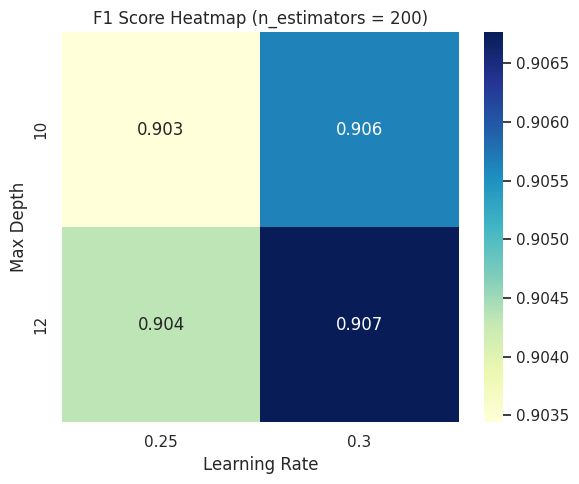

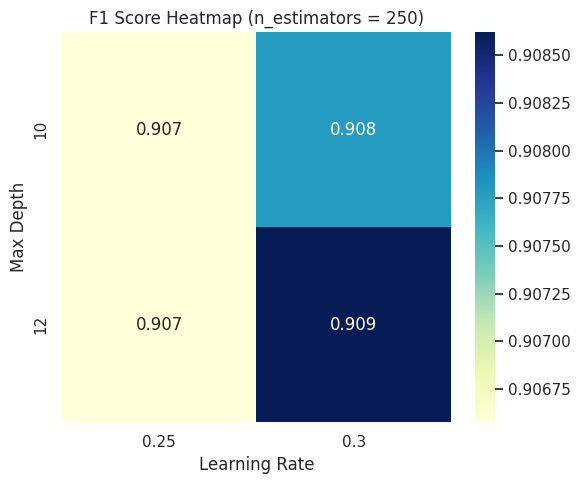

In [ ]:
#convert GridSearchCV results into a clean df
params_df = pd.DataFrame(grid_search.cv_results_['params'])
scores_df = pd.DataFrame(grid_search.cv_results_['mean_test_score'], columns=['mean_test_score'])
merged_df = pd.concat([params_df, scores_df], axis=1)

#display a leaderboard table of best param combinations
print("🔝 Top Grid Search Results by F1 Score:")
display(merged_df.sort_values(by='mean_test_score', ascending=False).reset_index(drop=True))

#visual Heatmaps of mean_test_score vs max_depth & learning_rate (faceted by n_estimators)
merged_df['learning_rate'] = merged_df['learning_rate'].astype(str)
sns.set(style="whitegrid")

# Create heatmaps for each value of n_estimators
unique_estimators = merged_df['n_estimators'].unique()
for est in sorted(unique_estimators):
    subset = merged_df[merged_df['n_estimators'] == est]
    pivot = subset.pivot_table(
        index='max_depth',
        columns='learning_rate',
        values='mean_test_score',
        aggfunc='mean'
    )
    plt.figure(figsize=(6, 5))
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGnBu")
    plt.title(f"F1 Score Heatmap (n_estimators = {est})")
    plt.ylabel("Max Depth")
    plt.xlabel("Learning Rate")
    plt.tight_layout()
    plt.show()

#3D plot using plotly
try:
    import plotly.express as px
    fig = px.scatter_3d(
        merged_df,
        x='max_depth',
        y='learning_rate',
        z='n_estimators',
        color='mean_test_score',
        size='mean_test_score',
        title='XGBoost Grid Search Results (F1 Score)'
    )
    fig.show()
except ImportError:
    print("Plotly not installed. Run `!pip install plotly` to enable interactive 3D visualization.")

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

#use the best model found from grid search
best_model = grid_search.best_estimator_

#predict on test set
y_pred_best = best_model.predict(X_test_xgb)

#evaluate the performance
print("📉 Confusion Matrix:")
print(confusion_matrix(y_test_xgb, y_pred_best))

print("\n📊 Classification Report:")
print(classification_report(y_test_xgb, y_pred_best))

📉 Confusion Matrix:
[[1270664     233]
 [    113    1514]]

📊 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270897
           1       0.87      0.93      0.90      1627

    accuracy                           1.00   1272524
   macro avg       0.93      0.97      0.95   1272524
weighted avg       1.00      1.00      1.00   1272524



**Calculate $$ amounts**

In [ ]:
#add predictions back to the test set
X_test_xgb_copy = X_test_xgb.copy()
X_test_xgb_copy['true_label'] = y_test_xgb
X_test_xgb_copy['predicted'] = y_pred_best

#ensure amount column is available in test set
X_test_xgb_copy['amount'] = X_xgb.loc[X_test_xgb_copy.index, 'amount']

#filter predictions

#fn
fn = X_test_xgb_copy[(X_test_xgb_copy['true_label'] == 1) & (X_test_xgb_copy['predicted'] == 0)]
total_FN_loss = fn['amount'].sum()

#fp
fp = X_test_xgb_copy[(X_test_xgb_copy['true_label'] == 0) & (X_test_xgb_copy['predicted'] == 1)]
total_FP_loss = fp['amount'].sum()

#tp
tp = X_test_xgb_copy[(X_test_xgb_copy['true_label'] == 1) & (X_test_xgb_copy['predicted'] == 1)]
total_TP_saved = tp['amount'].sum()

#total
total_test_amount = X_test_xgb_copy['amount'].sum()

#print
print(f"💸 Undetected Fraud (False Negatives): ${total_FN_loss:,.2f}")
print(f"💸 Legit Transactions Flagged (False Positives): ${total_FP_loss:,.2f}")
print(f"💰 Fraud Caught and Saved (True Positives): ${total_TP_saved:,.2f}")
print(f"📊 Total $ Value of All Test Transactions: ${total_test_amount:,.2f}")

💸 Undetected Fraud (False Negatives): $25,357,261.79
💸 Legit Transactions Flagged (False Positives): $74,218,333.74
💰 Fraud Caught and Saved (True Positives): $2,246,970,478.93
📊 Total $ Value of All Test Transactions: $228,513,915,447.56


In [ ]:
#here calc what the avg/median/std dev, etc is for fraud's transaction amt
#stretch opportunity: calculate recurring transactions (by amt, account num)
#imbalanced dataset problem: although solved using logistic regression and random forest, if u need to imporve model try using oversampling SMOTE

next steps:
*   voting classifier/stacking (combine multiple models)
*   feature engineering
*   outlier detection models
*   explainability tools (why smth is flagged as fraud)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, f1_score

#reuse X_rf, y_rf from previous step
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X_rf, y_rf, test_size=0.2, random_state=42)

#define the random forest pipeline
rf_pipeline = Pipeline([
    ('rf', RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1))
])

#define the parameter search space
param_dist_rf = {
    'rf__n_estimators': randint(100, 150),
    'rf__max_depth': [None] + list(range(5, 20)),
    'rf__min_samples_split': randint(2, 10),
    'rf__min_samples_leaf': randint(1, 5),
    'rf__max_features': ['sqrt', 'log2', None]
}

#define custom scorer (using F1 to balance precision/recall)
def f1_threshold_scorer(threshold=0.5):
    def scorer(estimator, X, y):
        probs = estimator.predict_proba(X)[:, 1]
        preds = (probs > threshold).astype(int)
        return f1_score(y, preds)
    return make_scorer(scorer)

#run randomized search
search_rf = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_dist_rf,
    n_iter=5, # Reduced number of iterations
    scoring=f1_threshold_scorer(0.5),
    cv=2, # Reduced cross-validation folds
    verbose=2,
    n_jobs=-1,
    random_state=42
)

#fit search
search_rf.fit(X_train_rf, y_train_rf)

#show best parameters
print("🔍 Best Hyperparameters:")
print(search_rf.best_params_)

#predict using best model
best_rf = search_rf.best_estimator_
y_probs_rf = best_rf.predict_proba(X_test_rf)[:, 1]
y_pred_rf = (y_probs_rf > 0.5).astype(int)  # or adjust threshold later if needed

#evaluate
from sklearn.metrics import classification_report, confusion_matrix
print("\nClassification Report:")
print(classification_report(y_test_rf, y_pred_rf, digits=4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_rf, y_pred_rf))